- 캐글 설치

In [7]:
!pip install kaggle

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


- 캐글에서 titanic 데이터셋 다운로드 및 압축해제
- train.csv 로딩 후 데이터 크기 확인

In [2]:
import os
import pandas as pd
import zipfile
import kaggle
# import numpy as np
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import LabelEncoder

In [4]:
# 캐글 API를 사용하여 타이타닉 데이터셋 다운로드 (경연 대회 데이터)
# 터미널 명령어인 '!kaggle competitions download -c titanic' 과 동일한 역할 수행

# 1. 파일이 존재하는지 먼저 확인하고 다운로드
if not os.path.exists('titanic.zip'):
    print("파일 다운로드 중...")
    # !를 붙이는 건 주피터 노트북 환경일 때 사용, 일반 파이썬은 os.system 사용
    # os.system('kaggle competitions download -c titanic')
    kaggle.api.competition_download_files('titanic', path='.')
    
# 다운로드된 압축 파일 해제 (운영체제에 따라 zipfile 라이브러리 사용 권장)
if os.path.exists('titanic.zip'):
    with zipfile.ZipFile('titanic.zip', 'r') as zip_ref:
        zip_ref.extractall('.')
    print("압축 해제 완료!")
    
    # 3. 데이터 로드
    df = pd.read_csv('train.csv')
    print(df.head(3))
else:
    print("에러: titanic.zip 파일이 다운로드되지 않았습니다. 캐글 API 설정을 확인하세요.")

압축 해제 완료!
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  


In [29]:
df = pd.read_csv('train.csv')
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


- 결측치 확인 및 대체

In [32]:
# 결측치 확인
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [31]:
# 1. Age(나이) 결측치: 데이터의 중앙값(median)으로 대체
df['Age']=df['Age'].fillna(df['Age'].median())

# 2. Embarked(탑승 항구) 결측치: 최빈값(mode)으로 대체 (결측치가 2개뿐이므로)
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

# 3. Cabin(객실 번호) 결측치: 결측치가 너무 많아(600개 이상) 열 자체를 삭제하거나, 
# 결측치 자체를 의미 있는 'Unknown'이라는 범주로 대체할 수 있습니다.
# 여기서는 'U' (Unknown)로 대체합니다.
df['Cabin']=df['Cabin'].fillna('U')

- 성별(sex)과 탑승 항구(Embarked) 컬럼 인코딩

In [33]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [34]:
from sklearn.preprocessing import LabelEncoder
# 1. Sex(성별): 'male', 'female' 두 가지이므로 0과 1로 매핑 (Label Encoding과 유사)
# le = LabelEncoder()
# df['Sex'] = le.fit_transform(df['Sex'])
df.Sex = df.Sex.map({'male':0, 'female':1}) # 위 방법과 결과가 정반대가 됨

In [35]:
# 2. Embarked(탑승 항구): 'C', 'Q', 'S' 세 가지이며 순서가 없으므로 원-핫 인코딩
# pd.get_dummies를 사용하고 기존 컬럼은 삭제, 다중공선성 방지를 위해 drop_first=True 적용
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,U,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,U,False,True


- 지금까지 작업한 내용 확인

In [17]:
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,U,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,U,False,True


- 나이(Age)와 요금(Fare)는 표준화 작업( 컬럼명 : 'Age_scaled', 'Fare_scaled' )

In [36]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# StandardScaler를 사용하여 평균 0, 표준편차 1로 맞춤
std_scaler = StandardScaler()
# df_std = pd.DataFrame(std_scaler.fit_transform(df[['Age', 'Fare']]), columns=['Age_scaled', 'Fare_scaled'])
df[['Age_scaled', 'Fare_scaled']] = std_scaler.fit_transform(df[['Age', 'Fare']])

In [37]:
# df[['Age_scaled', 'Fare_scaled']] = std_scaler.fit_transform(df[['Age', 'Fare']])
# 2차원 배열 형태로 입력해야 하므로 [['Age', 'Fare']] 형태로 묶어줌
mms_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(mms_scaler.fit_transform(df[['Age', 'Fare']]), columns=['Age_scaled', 'Fare_scaled'])
# df[['Age_mms', 'Fare_mms']] = mms_scaler.fit_transform(df[['Age', 'Fare']])
df_minmax.head(3)

,Age_scaled,Fare_scaled
0,0.271174,0.014151
1,0.472229,0.139136
2,0.321438,0.015469


- 요금은 로그변환, 나이는 5개의 범주형 그룹으로 구간화
- 0, 12, 18, 35, 60, 100
- 'Child', 'Teenager', 'Young Adult', 'Adult', 'Senior'

In [38]:
import numpy as np

# 1. 데이터 변환: 요금(Fare) 데이터의 비대칭성을 줄이기 위해 로그 변환 적용
# 요금이 0인 경우가 있으므로 np.log1p (log(1+x)) 사용
df['fare_log'] = np.log1p(df['Fare'])

# 2. 구간화(Binning): 나이(Age)를 5개의 범주형 그룹으로 나눔
bins = [0,12,18,35,60,100]
labels = ['Child', 'Teenager', 'Young Adult', 'Adult', 'Senior']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_Q,Embarked_S,Age_scaled,Fare_scaled,fare_log,Age_Group
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,U,False,True,-0.565736,-0.502445,2.110213,Young Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,False,False,0.663861,0.786845,4.280593,Adult
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,U,False,True,-0.258337,-0.488854,2.188856,Young Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,False,True,0.433312,0.420730,3.990834,Young Adult
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,U,False,True,0.433312,-0.486337,2.202765,Young Adult


- 파생변수(FamilySize : 가족수) 생성
- 가족 수 = 형제/배우자 수 + 부모/자녀 수 + 1(본인)
- 가족 규모에 따라 혼자 탑승했는지(IsAlone) 여부를 나타내는 파생 변수 추가 생성
- 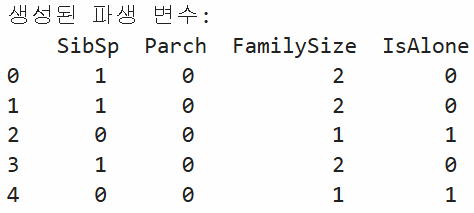

In [39]:
# 가족 수 = 형제/배우자 수 + 부모/자녀 수 + 1(본인)
df['FamilySize'] = df.SibSp + df.Parch + 1

# 가족 규모에 따라 혼자 탑승했는지(IsAlone) 여부를 나타내는 파생 변수 추가 생성
df['IsAlone'] = 0
df.loc[df['FamilySize']==1, 'IsAlone'] = 1

df[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head()

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


- 작업결과 출력

In [40]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_Q,Embarked_S,Age_scaled,Fare_scaled,fare_log,Age_Group,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,U,False,True,-0.565736,-0.502445,2.110213,Young Adult,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,False,False,0.663861,0.786845,4.280593,Adult,2,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,U,False,True,-0.258337,-0.488854,2.188856,Young Adult,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,False,True,0.433312,0.420730,3.990834,Young Adult,2,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,U,False,True,0.433312,-0.486337,2.202765,Young Adult,1,1


- 불필요한 컬럼 삭제( 'Ticket', 'Name' )

In [41]:
df = df.drop(['Ticket', 'Name'], axis=1)
df

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked_Q,Embarked_S,Age_scaled,Fare_scaled,fare_log,Age_Group,FamilySize,IsAlone
0,1,0,3,0,22.0,1,0,7.2500,U,False,True,-0.565736,-0.502445,2.110213,Young Adult,2,0
1,2,1,1,1,38.0,1,0,71.2833,C85,False,False,0.663861,0.786845,4.280593,Adult,2,0
2,3,1,3,1,26.0,0,0,7.9250,U,False,True,-0.258337,-0.488854,2.188856,Young Adult,1,1
3,4,1,1,1,35.0,1,0,53.1000,C123,False,True,0.433312,0.420730,3.990834,Young Adult,2,0
4,5,0,3,0,35.0,0,0,8.0500,U,False,True,0.433312,-0.486337,2.202765,Young Adult,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,0,27.0,0,0,13.0000,U,False,True,-0.181487,-0.386671,2.639057,Young Adult,1,1
887,888,1,1,1,19.0,0,0,30.0000,B42,False,True,-0.796286,-0.044381,3.433987,Young Adult,1,1
888,889,0,3,1,28.0,1,2,23.4500,U,False,True,-0.104637,-0.176263,3.196630,Young Adult,4,0
889,890,1,1,0,26.0,0,0,30.0000,C148,False,False,-0.258337,-0.044381,3.433987,Young Adult,1,1


In [42]:
df.shape

(891, 17)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Sex          891 non-null    int64   
 4   Age          891 non-null    float64 
 5   SibSp        891 non-null    int64   
 6   Parch        891 non-null    int64   
 7   Fare         891 non-null    float64 
 8   Cabin        891 non-null    object  
 9   Embarked_Q   891 non-null    bool    
 10  Embarked_S   891 non-null    bool    
 11  Age_scaled   891 non-null    float64 
 12  Fare_scaled  891 non-null    float64 
 13  fare_log     891 non-null    float64 
 14  Age_Group    891 non-null    category
 15  FamilySize   891 non-null    int64   
 16  IsAlone      891 non-null    int64   
dtypes: bool(2), category(1), float64(5), int64(8), object(1)
memory usage: 10